# Trimer Case II: Unraveling transitions

Using the Monte Carlo wavefunction method, we generates fictitious dynamics of wavefunction, from which we learn the transition statistics.

In [55]:
# get the definition of functions.
%run trimer-case2-functions.ipynb

In [56]:
# parameter values
omega0 = 1
gamma0 = 0.1
temperature = 1

k0,lambda0 = scale(omega0)

# distance between emitters 
a = 0.5*lambda0

NT = planck_dist(omega0,temperature)

v, label = pbasis()

In [57]:
sz, sp, sm = spin_ops()
H, Omega = hamiltonian(omega0,a)
Gamma, gamma, I0 = decay_rate(gamma0,a)
L, c_ops = collapse_ops(gamma,NT)

In [58]:
#--- the ground state as initial state
psi0 = v[7]

# execution time (trying to get 1000 photons)
tmax = 500 / gamma0
# number of time sampling points
tsample = 5000
times = np.linspace(0, tmax, tsample)

# options for mcsolver
opts={"store_states": True,"keep_runs_results": True, "progress_bar": False}

# get a trajectory
result = mcsolve(H,psi0,times,c_ops,e_ops=sz,ntraj=1,options=opts)

In [59]:
# get results
t_jump = np.array(result.col_times[0]) # time of all jumps
ch_jump = np.array(result.col_which[0]) # channel of all jumps

# emission time for each emitters
te_1 = t_jump[ch_jump==0]
te_2 = t_jump[(ch_jump==1) | (ch_jump==2)]
te_all = t_jump[(ch_jump==0) | (ch_jump==1) | (ch_jump==2)]

# absorption time for each quantum dot
ta_1 = t_jump[ch_jump==3]
ta_2 = t_jump[(ch_jump==4) | (ch_jump==5)]
ta_all = t_jump[(ch_jump==3) | (ch_jump==4) | (ch_jump==5)]

print("** Jump counts  **")
print(" superradiant ch: emission count={0:4d}   absorption count={1:4d}".format(np.size(te_1), np.size(ta_1)))
print("   subradiant ch: emission count={0:4d}   absorption count={1:4d}".format(np.size(te_2), np.size(ta_2)))
print("           total: emission count={0:4d}   absorption count={1:4d}".format(np.size(te_all), np.size(ta_all)))

** Jump counts  **
 superradiant ch: emission count= 126   absorption count= 143
   subradiant ch: emission count= 483   absorption count= 468
           total: emission count= 609   absorption count= 611


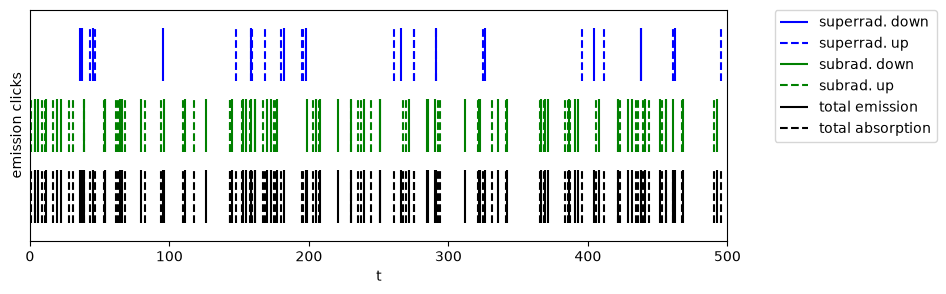

In [60]:
plt.figure(figsize=(9, 3))

# emissions: detector clicks
plt.vlines(te_1, 2.0, 2.75, color="b", label="superrad. down")
plt.vlines(ta_1, 2.0, 2.75, color="b", ls='--',label="superrad. up")
plt.vlines(te_2, 1.0, 1.75, color="g", label="subrad. down")
plt.vlines(ta_2, 1.0, 1.75, color="g", ls='--',label="subrad. up")
plt.vlines(te_all, 0.0, 0.75, color="k", label="total emission")
plt.vlines(ta_all, 0.0, 0.75, color="k", ls='--',label="total absorption")

plt.ylabel("emission clicks")
plt.xlabel("t")
plt.xlim([0,500])
plt.ylim(-.25, 3.0)
plt.yticks([])
plt.legend(bbox_to_anchor=(1.30, 1), borderaxespad=0)
plt.show()

In [61]:
tlist = np.linspace(0, 4000, 8000)

# the number of realizations
ntraj = 200

# MCWF
res = mcsolve(H, v[7], tlist, c_ops, e_ops=[], ntraj=ntraj,
              options={"keep_runs_results": True,"progress_bar": False})

# get waiting time 
wtime = []
emit = []
for k in range(ntraj):
    tj = np.asarray(res.col_times[k])  # accumulate all jumps
    ch = np.asarray(res.col_which[k])  # accumulate channel info

    # all channels
    emit = tj[(ch == 1) | (ch == 2) | (ch == 3)]
    wtime.append(np.diff(emit))


wtime = np.concatenate(wtime)


In [62]:

print("Waiting time statistics")
print("photons     mean   deviation")
photons=wtime.size
mean = wtime.mean()
dev = np.sqrt((wtime**2).mean() - mean**2)
print(" {0:7d}  {1:7.3f}  {1:7.3f}".format(photons, mean, dev))


Waiting time statistics
photons     mean   deviation
  101834    7.822    7.822


Since mean waiting time coincides with the standard deviation, it seems a poisson process.

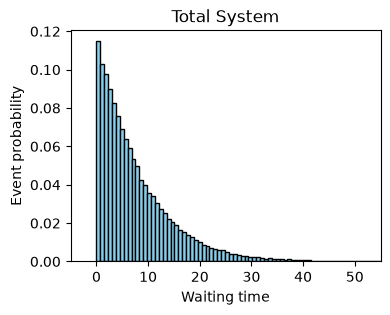

In [63]:
plt.figure(figsize=(4,3))
plt.hist(wtime, density=True, bins=100, color='skyblue', edgecolor='black')
plt.xlim([-5,55])
# plt.ylim([0,0.1])
plt.title("Total System")
plt.xlabel("Waiting time")
plt.ylabel("Event probability")
plt.show()

## Second-order coherence of all photons emitted

In [64]:
#--- calculate histogram
def hist(t,dtau,count):
    # ordered pairs, positive delay
    for i in range(t.size): 
        dt = t[i + 1:] - t[i]
        window = dt < tau_max
        if not np.any(window):
            continue
        b = np.floor(dt[window]/dtau).astype(int)
        np.add.at(count, b, 1)
    return

#--- counting parameters
tau_max = 100
dtau = 0.5

#--- edges of bins
edges = np.arange(0.0, tau_max + dtau, dtau)

#--- counting storages
counts = np.zeros( edges.size - 1)  # all emitters

#--- extract data from multiple runs
clicks=0

for k in range(ntraj):
    tj = np.asarray(res.col_times[k])
    ch = np.asarray(res.col_which[k])
    ts = tj[(ch == 3) | (ch == 4) | (ch == 5)]

    # all channels
    hist(ts,dtau,counts)
    clicks+=ts.size

#--- normalize the counts
norm = clicks**2 / tlist[-1] / ntraj * dtau
g2 = counts / norm
tau = 0.5 * (edges[:-1] + edges[1:]) 


Since there is no coherence among the emitters and the detector  integrated the phases, we get the standard no-delay coherence $g^{(2)}(0) = \tfrac23$.

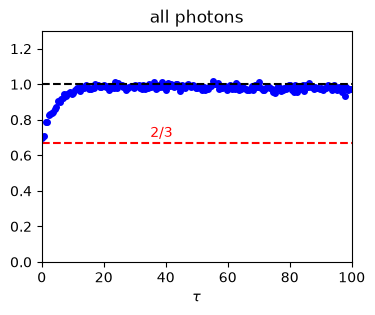

In [68]:
# g2 of all photons from the three emitters
plt.figure(figsize=(4,3))
plt.title("all photons")
plt.ylim([0,1.3])
plt.plot(tau,g2, ls='', marker='o', markersize=4, markerfacecolor='b', markeredgecolor='b',label="all emitters")
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel("")
plt.axhline(y=1, color='k', linestyle='--')
plt.axhline(y=2/3, color='r', linestyle='--')
plt.text(35,0.7,"$2/3$",color="r")
plt.show()